In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load German Credit dataset
from sklearn.datasets import fetch_openml

data = fetch_openml('credit-g', version=1, as_frame=True)
df = data.frame

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head(5)

Dataset shape: (1000, 21)

Column names:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [5]:
print(data.DESCR)


**Author**: Dr. Hans Hofmann  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)) - 1994    
**Please cite**: [UCI](https://archive.ics.uci.edu/ml/citation_policy.html)

**German Credit dataset**  
This dataset classifies people described by a set of attributes as good or bad credit risks.

This dataset comes with a cost matrix: 
``` 
Good  Bad (predicted)  
Good   0    1   (actual)  
Bad    5    0  
```

It is worse to class a customer as good when they are bad (5), than it is to class a customer as bad when they are good (1).  

### Attribute description  

1. Status of existing checking account, in Deutsche Mark.  
2. Duration in months  
3. Credit history (credits taken, paid back duly, delays, critical accounts)  
4. Purpose of the credit (car, television,...)  
5. Credit amount  
6. Status of savings account/bonds, in Deutsche Mark.  
7. Present employment, in number of years.  
8. Installment rate in percentage of disposable income  
9. Perso

In [6]:
# Basic overview of the dataset
print("\nTarget variable distribution:")
print(df['class'].value_counts())
print("\nMissing values:")
print(df.isnull().sum().sum())


Target variable distribution:
class
good    700
bad     300
Name: count, dtype: int64

Missing values:
0


In [7]:
# Check data types of all columns
print(df.dtypes)

checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
class                     category
dtype: object


In [8]:
# Count unique values per column
print(df.nunique())

checking_status             4
duration                   33
credit_history              5
purpose                    10
credit_amount             921
savings_status              5
employment                  5
installment_commitment      4
personal_status             4
other_parties               3
residence_since             4
property_magnitude          4
age                        53
other_payment_plans         3
housing                     3
existing_credits            4
job                         4
num_dependents              2
own_telephone               2
foreign_worker              2
class                       2
dtype: int64


In [5]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class']


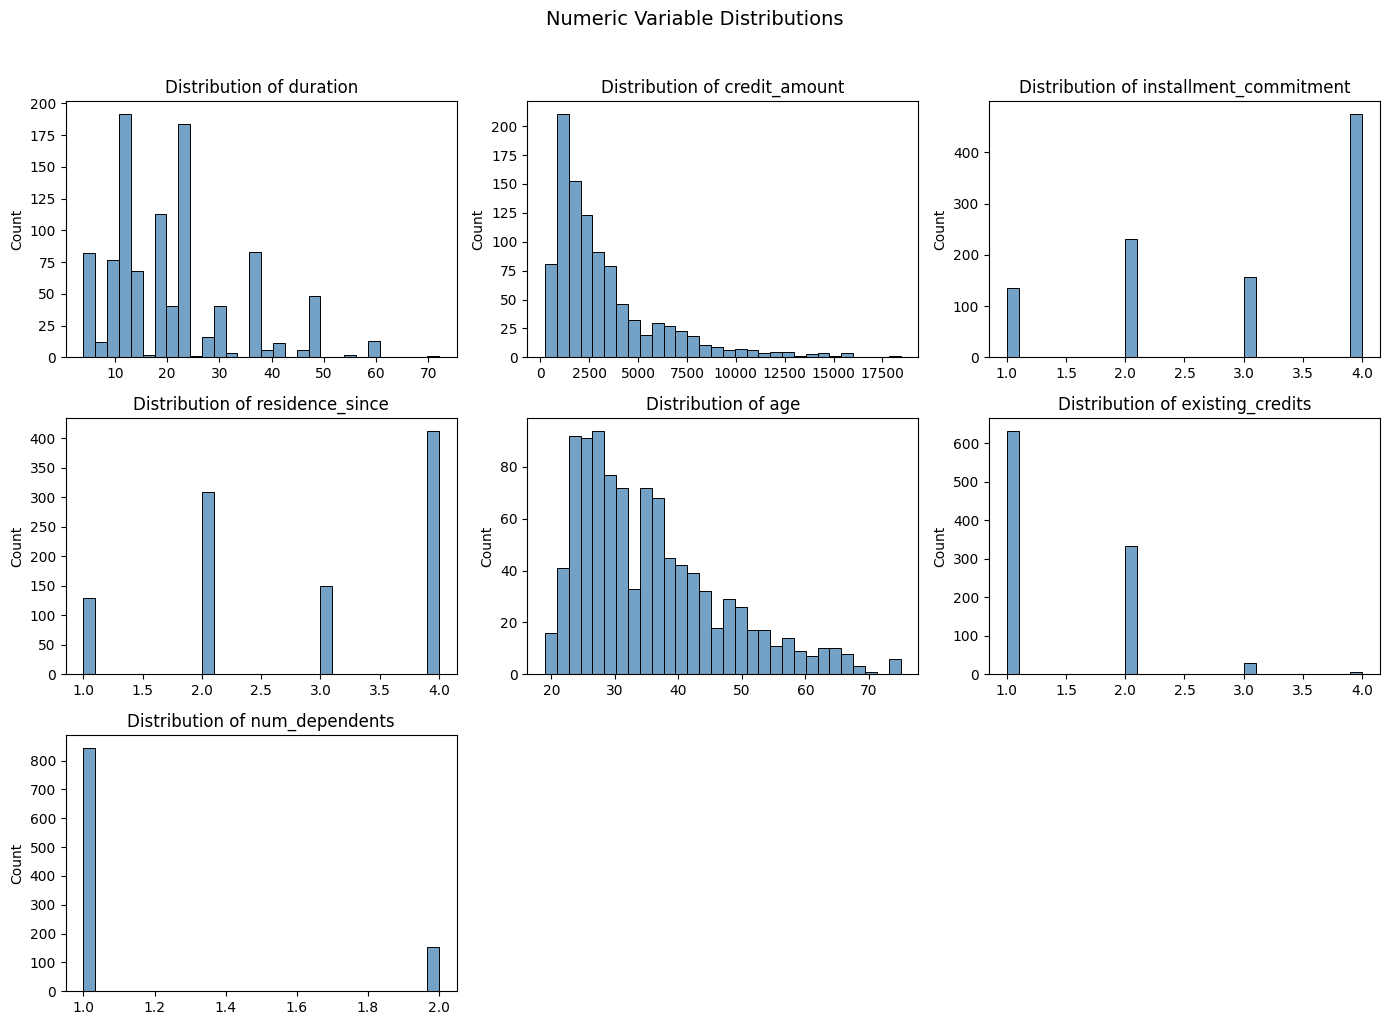

In [6]:
# Univariate analysis - numeric variables
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

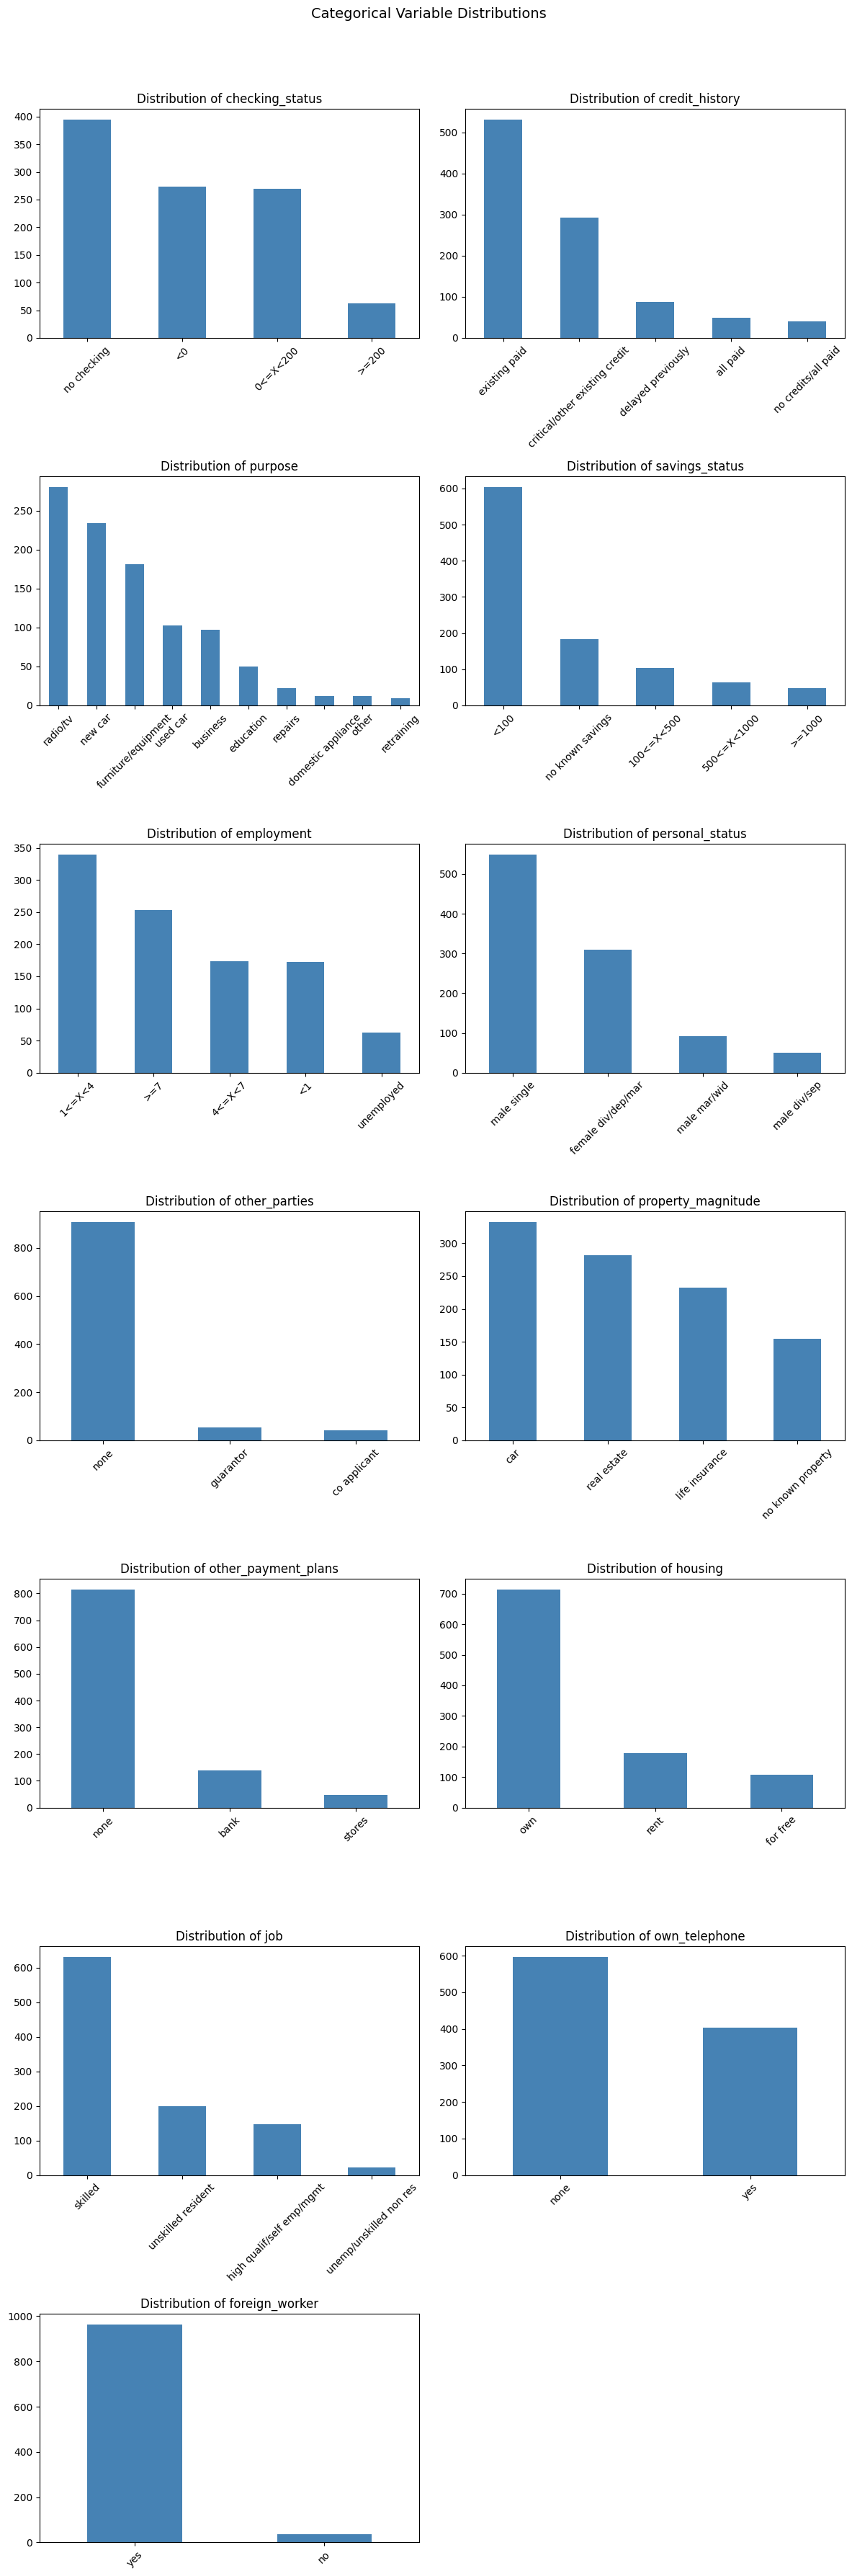

In [7]:
# Univariate analysis - categorical variables
categorical_cols_no_target = [col for col in categorical_cols if col != 'class']

fig, axes = plt.subplots(7, 2, figsize=(12, 35))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_no_target):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\paanh\AppData\Local\Temp\ipykernel_9656\2456074488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=col, ax=axes[i], palette='Blues')
C:\Users\paanh\AppData\Local\Temp\ipykernel_9656\2456074488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=col, ax=axes[i], palette='Blues')
C:\Users\paanh\AppData\Local\Temp\ipykernel_9656\2456074488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=col, ax=axes[i], palette='Blues')
C:\Users\paanh\AppData\Local\Temp\ipykernel

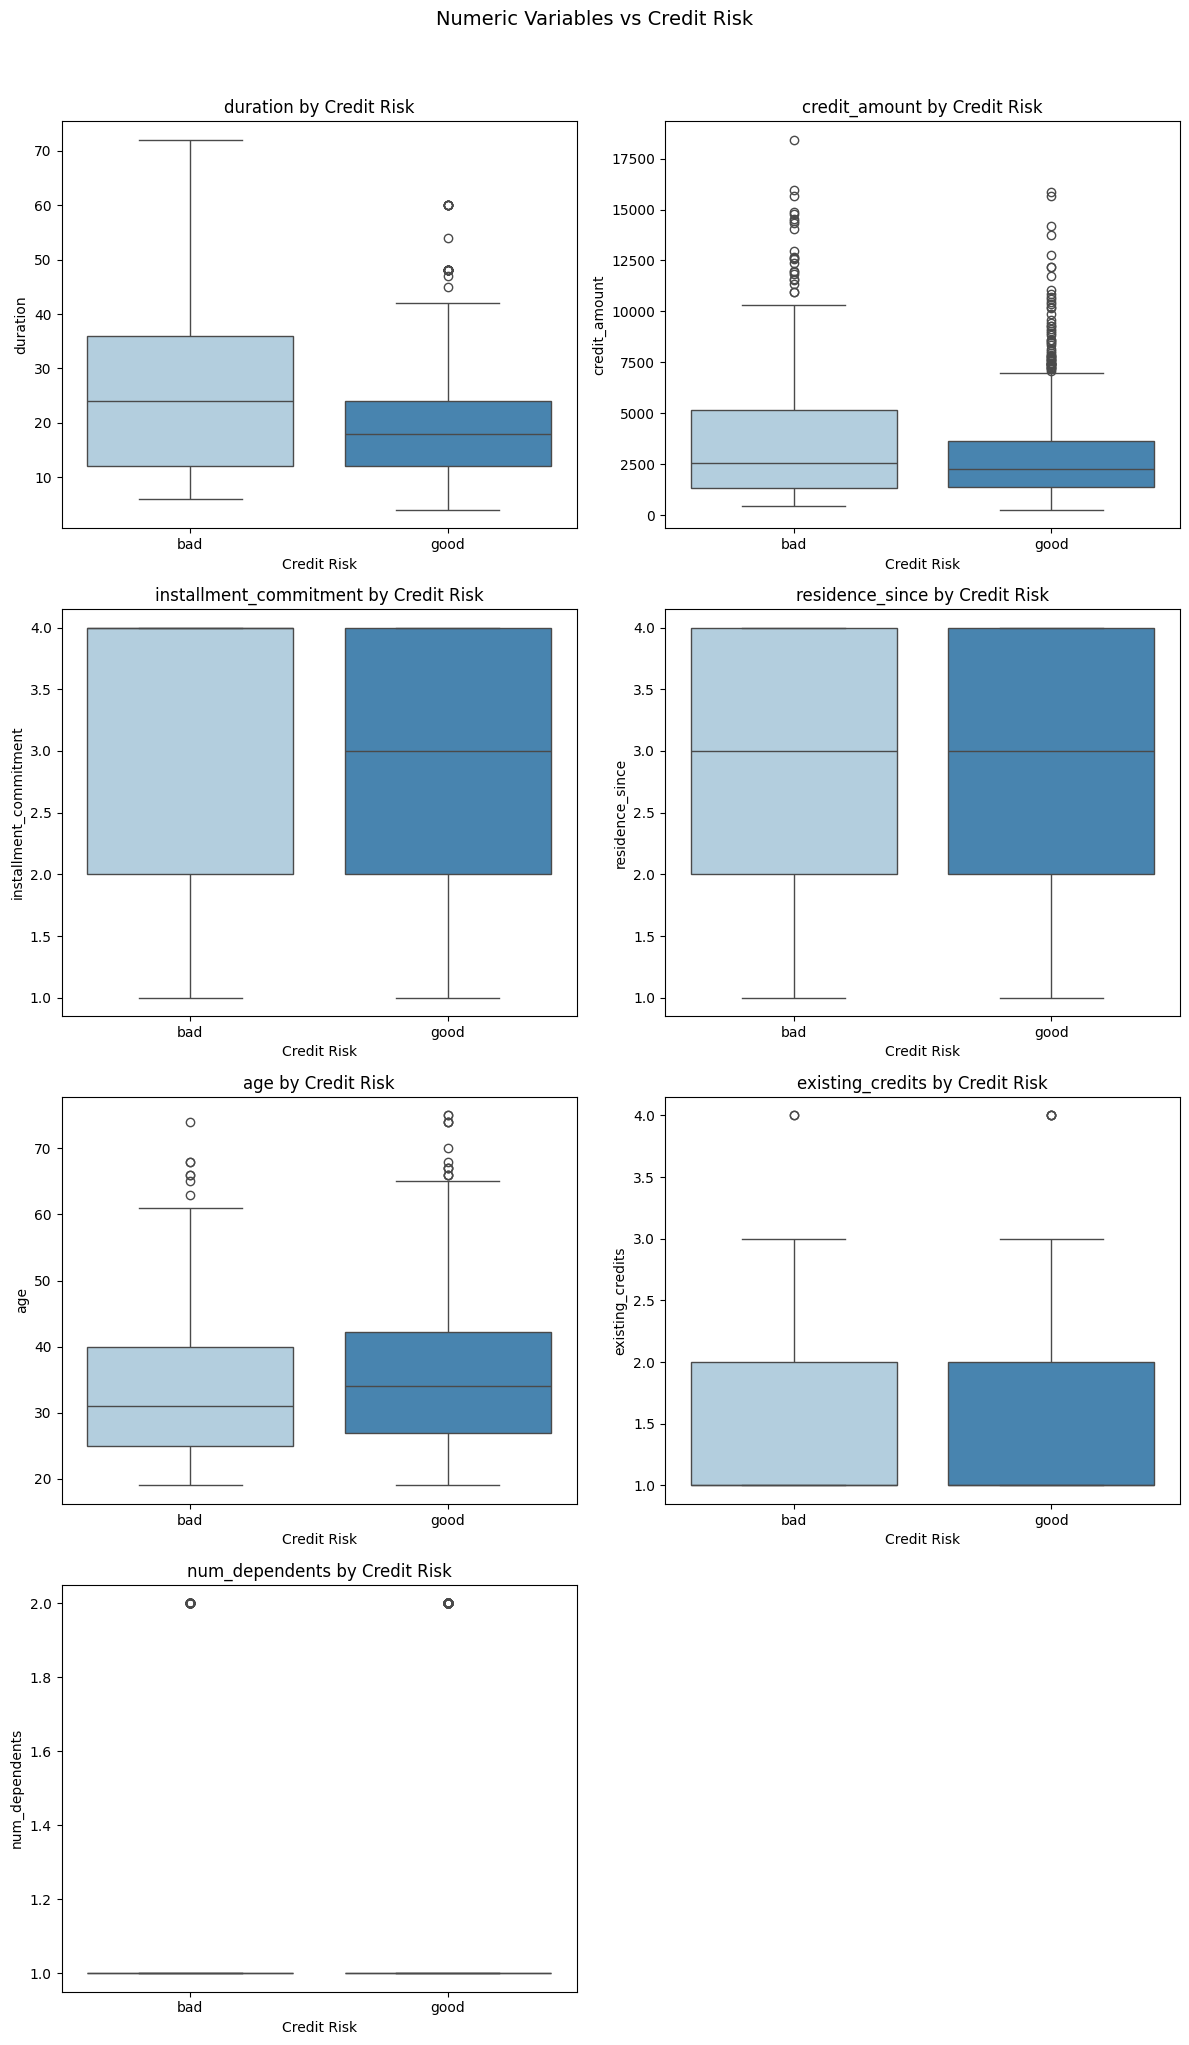

In [10]:
# Bivariate analysis - numeric variables vs target
fig, axes = plt.subplots(4, 2, figsize=(12, 20))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='class', y=col, ax=axes[i], palette='Blues')
    axes[i].set_title(f'{col} by Credit Risk')
    axes[i].set_xlabel('Credit Risk')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Variables vs Credit Risk', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

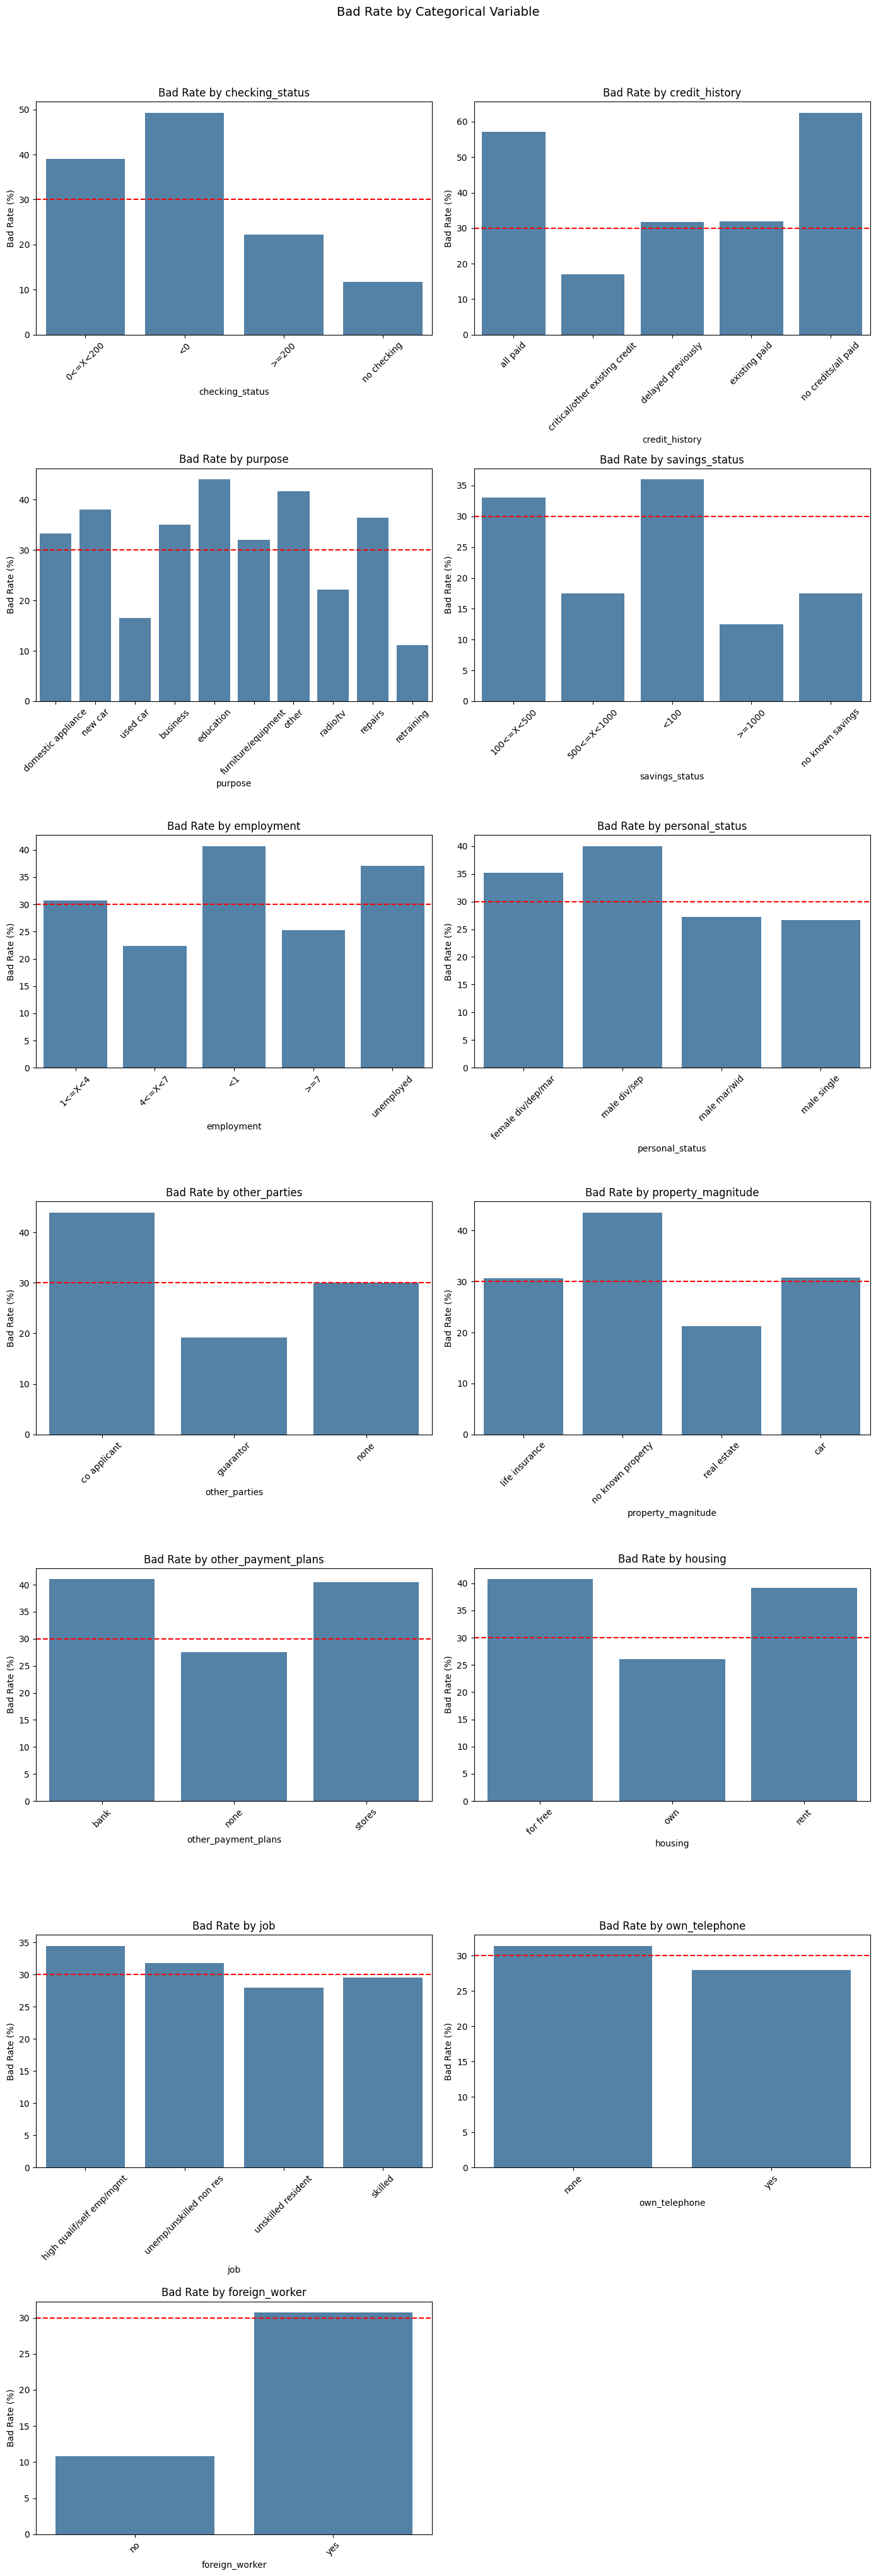

In [8]:
# Bivariate analysis - categorical variables vs target
fig, axes = plt.subplots(7, 2, figsize=(14, 40))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_no_target):
    bad_rate = df.groupby(col)['class'].apply(
        lambda x: (x == 'bad').sum() / len(x) * 100
    ).reset_index()
    bad_rate.columns = [col, 'bad_rate']
    
    sns.barplot(data=bad_rate, x=col, y='bad_rate', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Bad Rate by {col}')
    axes[i].set_ylabel('Bad Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=30, color='red', linestyle='--', label='Overall bad rate')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bad Rate by Categorical Variable', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

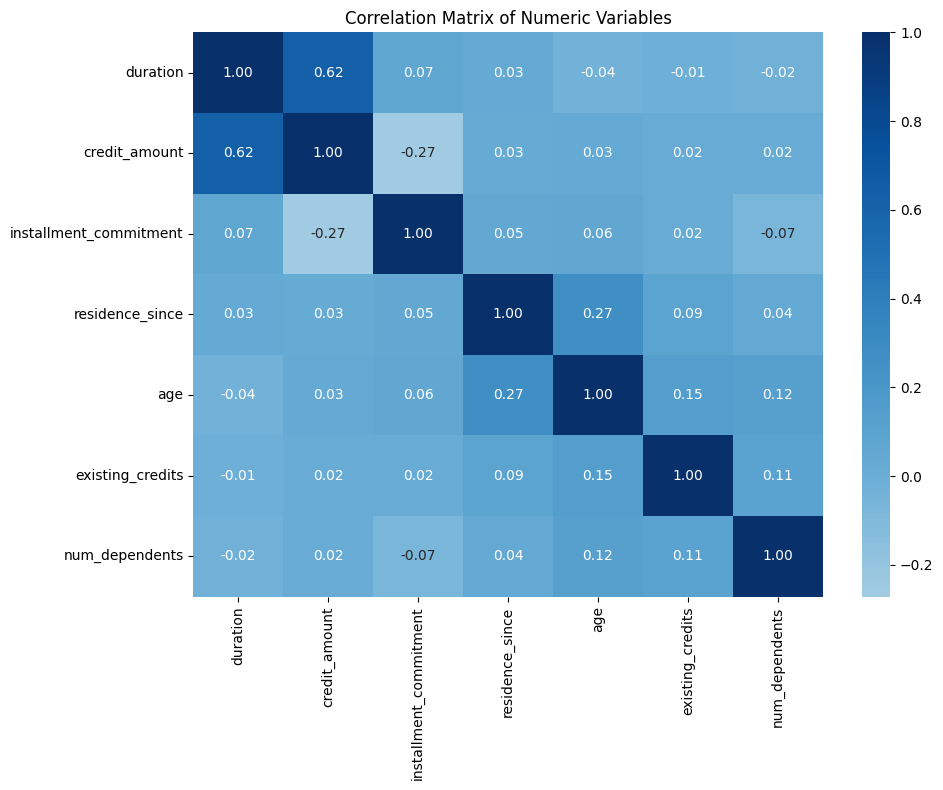

In [9]:
# Correlation matrix of numeric variables
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

## EDA Summary

### Dataset Overview
- 1000 observations, 20 features, 1 target variable (class: good/bad)
- No missing values
- Class imbalance: 70% good, 30% bad — needs to be addressed in modeling with cost matrix

### Numeric Variables
- **duration** and **credit_amount** seem to be the most predictive numeric variables
- Bad customers are more likely to have longer loan durations and higher loan amounts
- **credit_amount** has significant outliers — log transformation required
- **age** is weakly predictive — older customers tend to be lower risk
- **installment_commitment**, **residence_since**, **existing_credits** have very few unique values 
- **num_dependents** shows almost no variation 
- **duration** and **credit_amount** are moderately correlated (0.62) — multicollinearity to monitor

### Categorical Variables
- **checking_status** — strong predictor, customers with no checking account are highest risk
- **credit_history** — strong predictor, counterintuitive pattern where "all paid" customers are riskier than "critical account" customers 
- **purpose**, **savings_status**, **employment** — appear moderately predictive
- **personal_status**, **foreign_worker** — potential fairness concerns

### Key Actions for Preprocessing
1. Log transform **credit_amount**
2. Treat **installment_commitment**, **residence_since**, **existing_credits** as categorical
3. Address class imbalance using class weights
4. Encode categorical variables using Weight of Evidence (WoE)
5. Review **num_dependents** after IV analysis — likely to drop